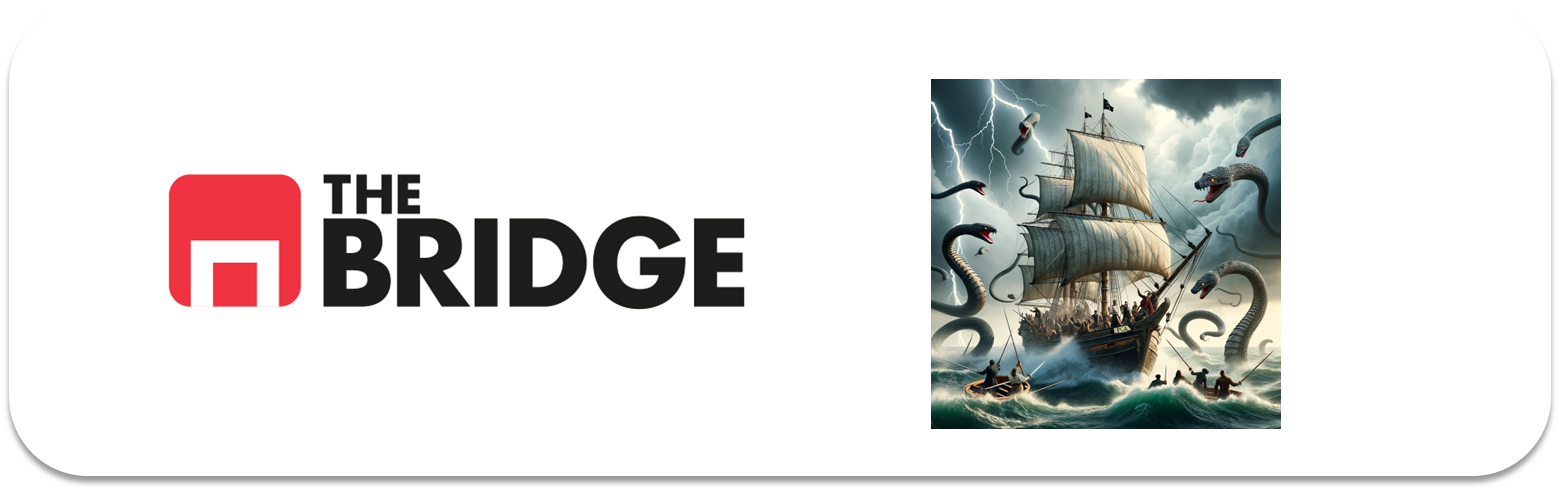

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Importación de paquetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC # Support Vector Classifier para las imágenes
from sklearn.metrics import balanced_accuracy_score
from sklearn.decomposition import PCA

# Configuración visual
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [3]:
# 1) Primero voy a descargar dataset y construir el df
faces = fetch_olivetti_faces()
X = faces.data # 400 imágenes - 4096 píxeles (64x64 pero aplanados)
y = faces.target # 40 clases (que son las 40 personas)

# 2) Split en train y test (Al menos 80 instancias en test -> 25% de 400 = 100)
# Estratificado según el target para tener la misma proporción de caras por persona
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape} (Cumple la condición de >= 80)")

# 3) Un miniEDA o justificación de omitir el EDA completo:
"""
Justificación para omitir un EDA exhaustivo:
El dataset Olivetti Faces ya viene preprocesado de la librería sklearn. 
Las imágenes están normalizadas en escala de grises (valores entre 0.0 y 1.0), 
no existen valores nulos y todas las imágenes tienen la misma dimensión 
aplanada de 4096 features. El target está perfectamente balanceado (10 fotos por persona).
"""

# * Construir y medir el modelo base
# Instancio el modelo
base_model = SVC(kernel='linear', random_state=42, class_weight='balanced')

# 4) Medir recall media (balanced_accuracy) con CV de 5 folds en train
cv_scores_base = cross_val_score(base_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
cv_base_mean = cv_scores_base.mean()

# Entrenar en todo el train y medir en test
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
test_base_score = balanced_accuracy_score(y_test, y_pred_base)

print(f"BASELINE - CV Balanced Accuracy (Media): {cv_base_mean:.4f}")
print(f"BASELINE - Test Balanced Accuracy:       {test_base_score:.4f}")

Tamaño de X_train: (300, 4096)
Tamaño de X_test: (100, 4096) (Cumple la condición de >= 80)
BASELINE - CV Balanced Accuracy (Media): 0.9475
BASELINE - Test Balanced Accuracy:       0.9792


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [4]:
# 1) Instanciar PCA sobre datos de train sin especificar componentes
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# 2) Escoger rango de valores
# Total de features originales = 4096
# Compresión del 0.2% = 4096 * 0.002 ≈ 8 componentes
# Compresión del 2.5% = 4096 * 0.025 ≈ 102 componentes
n_components_list = [8, 25, 50, 75, 102]

# 3 y 4) Entrenar modelos y guardar resultados
resultados_microcamaras = []

for n in n_components_list:
    # Aplicar PCA
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Calculo % de compresión
    compresion_pct = (n / X.shape[1]) * 100
    
    # Modelo
    model_pca = SVC(kernel='linear', random_state=42, class_weight='balanced')
    
    # CV Score
    cv_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='balanced_accuracy')
    cv_mean = cv_scores.mean()
    
    # Test Score
    model_pca.fit(X_train_pca, y_train)
    y_pred = model_pca.predict(X_test_pca)
    test_score = balanced_accuracy_score(y_test, y_pred)
    
    # Diferencias (Puntos porcentuales, multiplicado por 100 para verlo en %)
    diff_cv = (cv_mean - cv_base_mean) * 100
    diff_test = (test_score - test_base_score) * 100
    
    resultados_microcamaras.append({
        'N_Componentes': n,
        '% Compresion': f"{compresion_pct:.2f}%",
        'Score_CV': round(cv_mean, 4),
        'Score_Test': round(test_score, 4),
        'Diff_CV_Base (%)': round(diff_cv, 2),
        'Diff_Test_Base (%)': round(diff_test, 2)
    })

df_microcamaras = pd.DataFrame(resultados_microcamaras)
display(df_microcamaras)

# 5) Escoger el número de componentes (Análisis)
print("\n--- ANÁLISIS ---")
print("Buscamos la mayor compresión (menor N_Componentes) donde la pérdida 'Diff' sea mejor que -3.00%")
print("Observando el DataFrame, selecciona el valor que cumpla este criterio (por ejemplo, suele ser alrededor de 50 o 75 dependiendo del split).")

,N_Componentes,% Compresion,Score_CV,Score_Test,Diff_CV_Base (%),Diff_Test_Base (%)
0,8,0.20%,0.8125,0.8583,-13.50,-12.08
1,25,0.61%,0.9425,0.9792,-0.50,0.00
2,50,1.22%,0.9450,0.9792,-0.25,0.00
3,75,1.83%,0.9450,0.9792,-0.25,0.00
4,102,2.49%,0.9450,0.9792,-0.25,0.00



--- ANÁLISIS ---
Buscamos la mayor compresión (menor N_Componentes) donde la pérdida 'Diff' sea mejor que -3.00%
Observando el DataFrame, selecciona el valor que cumpla este criterio (por ejemplo, suele ser alrededor de 50 o 75 dependiendo del split).


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

,N_Componentes,% Compresion,Balanced_Accuracy,Diff_vs_Baseline (%)
0,4,0.10%,0.5542,-42.50
1,10,0.24%,0.9208,-5.83
2,20,0.49%,0.9792,0.00
3,30,0.73%,0.9708,-0.83
4,41,1.00%,0.9792,0.00


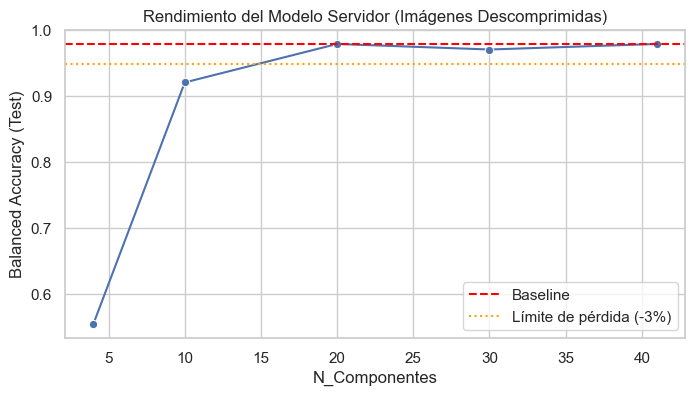


--- RECOMENDACIÓN ---
Basándote en la tabla y la gráfica, escoge el N_Componentes más bajo que mantenga la Diff_vs_Baseline por encima de -3.00%. Si ninguno llega, escoge el que mejor se aproxime.


In [5]:
# 1) Rango de valores entre 1 por mil (0.1%) y 1 por ciento (1%)
# 0.1% de 4096 = 4 componentes. 1% de 4096 = 41 componentes.
n_components_server = [4, 10, 20, 30, 41]

# 2 y 3) Aplicar, entrenar y crear visualización
resultados_server = []

for n in n_components_server:
    # PCA y compresión
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Como descomprimir aplicando la inversa
    X_train_unzipped = pca.inverse_transform(X_train_pca)
    X_test_unzipped = pca.inverse_transform(X_test_pca)
    
    # Compresión calculada
    compresion_pct = (n / X.shape[1]) * 100
    
    # Entreno el modelo con la imagen reconstruida
    model_server = SVC(kernel='linear', random_state=42, class_weight='balanced')
    model_server.fit(X_train_unzipped, y_train)
    
    # Probamos contra test reconstruido...
    y_pred = model_server.predict(X_test_unzipped)
    test_score = balanced_accuracy_score(y_test, y_pred)
    
    # Diff vs test base
    diff_test = (test_score - test_base_score) * 100
    
    resultados_server.append({
        'N_Componentes': n,
        '% Compresion': f"{compresion_pct:.2f}%",
        'Balanced_Accuracy': round(test_score, 4),
        'Diff_vs_Baseline (%)': round(diff_test, 2)
    })

df_server = pd.DataFrame(resultados_server)
display(df_server)

# Visualización
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_server, x='N_Componentes', y='Balanced_Accuracy', marker='o')
plt.axhline(test_base_score, color='red', linestyle='--', label='Baseline')
plt.axhline(test_base_score - 0.03, color='orange', linestyle=':', label='Límite de pérdida (-3%)')
plt.title('Rendimiento del Modelo Servidor (Imágenes Descomprimidas)')
plt.ylabel('Balanced Accuracy (Test)')
plt.legend()
plt.show()

# 4) Conclusión
print("\n--- RECOMENDACIÓN ---")
print("Basándote en la tabla y la gráfica, escoge el N_Componentes más bajo que mantenga la Diff_vs_Baseline por encima de -3.00%. Si ninguno llega, escoge el que mejor se aproxime.")

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

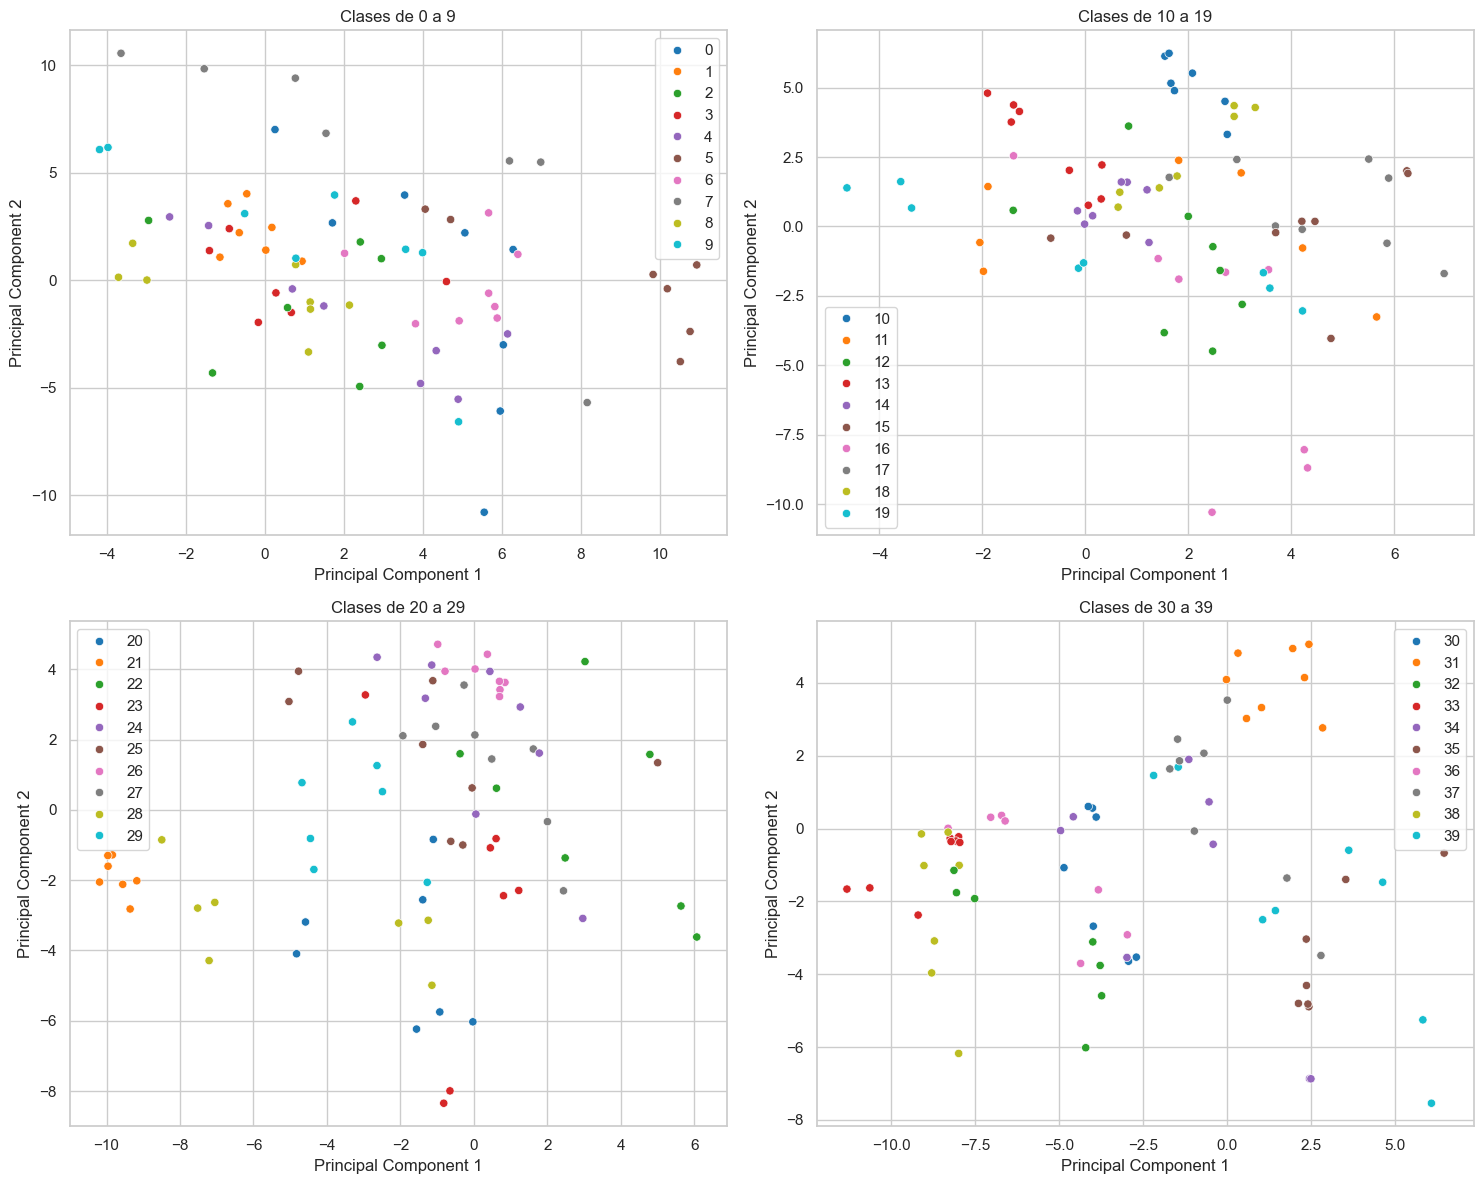

In [ ]:
# EXTRA 1

# Scatter plots de las dos primeras componentes principales coloreadas por clase
# Voy a usar la PCA elegida en el paso 2 (suponiendo que fue 75 o usaríamos una genérica)
pca_extra = PCA(n_components=2, random_state=42)
X_train_2d = pca_extra.fit_transform(X_train)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Hay 40 clases, dividiré en 4 rangos de 10 clases
rangos = [(0, 9), (10, 19), (20, 29), (30, 39)]

for i, (inicio, fin) in enumerate(rangos):
    ax = axes[i]
    # Filtro datos correspondientes a esas clases
    mask = (y_train >= inicio) & (y_train <= fin)
    
    sns.scatterplot(
        x=X_train_2d[mask, 0], 
        y=X_train_2d[mask, 1], 
        hue=y_train[mask], 
        palette='tab10', 
        ax=ax, 
        legend='full'
    )
    ax.set_title(f'Clases de {inicio} a {fin}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

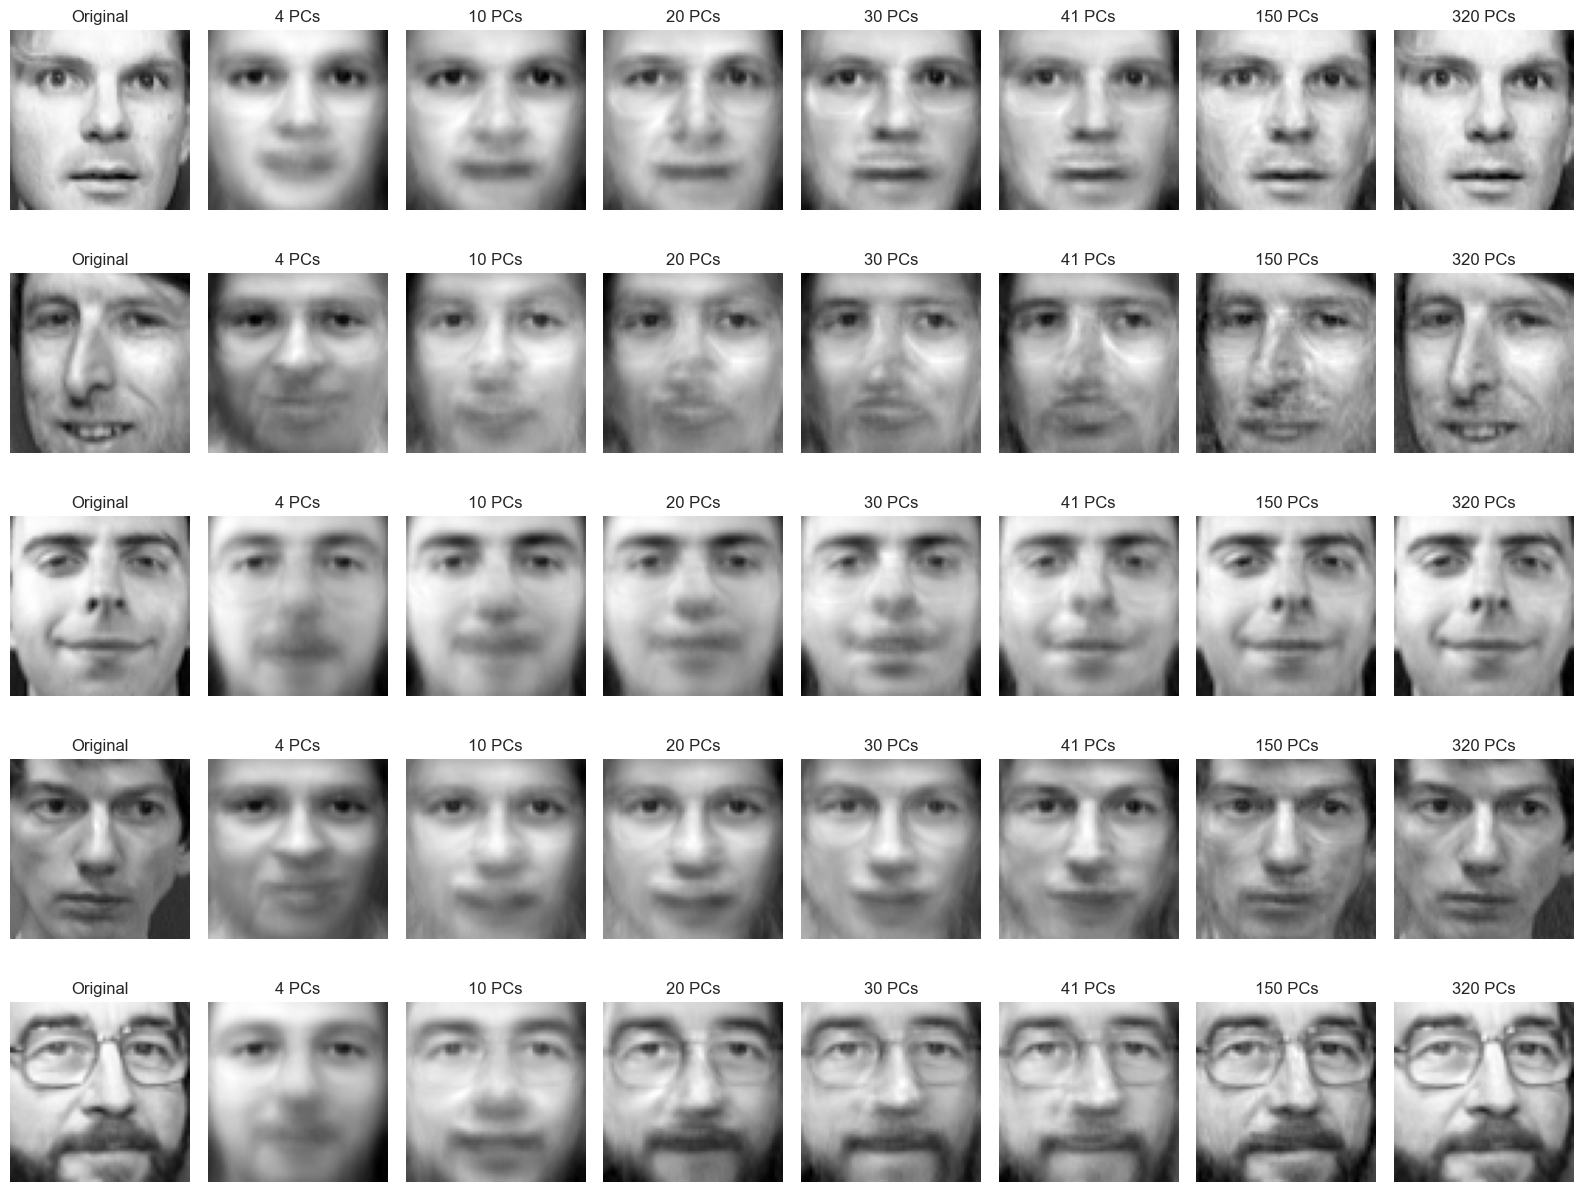

In [ ]:
# EXTRA 2

# Función para ver cara sin comprimir y tras la descompresión
def visualize_pca_reconstruction(X_data, image_indices, pcs_to_test):
    # pcs_to_test incluye los de la parte 3 y los extras pedidos
    
    n_images = len(image_indices)
    n_cols = len(pcs_to_test) + 1 # +1 para la original
    
    fig, axes = plt.subplots(n_images, n_cols, figsize=(2 * n_cols, 2.5 * n_images))
    
    for i, idx in enumerate(image_indices):
        img_original = X_data[idx]
        
        # Plot original
        axes[i, 0].imshow(img_original.reshape(64, 64), cmap='gray')
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')
        
        for j, n_pcs in enumerate(pcs_to_test):
            # Entrenar PCA específico para este número de componentes
            pca = PCA(n_components=n_pcs, random_state=42)
            pca.fit(X_data) # Ojo, fit sobre todos los datos disponibles
            
            # Comprimir y descomprimir
            img_compressed = pca.transform(img_original.reshape(1, -1))
            img_reconstructed = pca.inverse_transform(img_compressed)
            
            # Plot reconstruida
            axes[i, j+1].imshow(img_reconstructed.reshape(64, 64), cmap='gray')
            axes[i, j+1].set_title(f"{n_pcs} PCs")
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

# Lista de componentes probados en parte 3 + los exigidos en el ejercicio
pcs_a_probar = [4, 10, 20, 30, 41, 150, 320]

# Escoger 5 índices aleatorios, pero del dataset COMPLETO, antes me daba error por usar las de X_train
indices_aleatorios = np.random.choice(range(len(X)), 5, replace=False)

# Ejecutamos la función sobre 'X' (400 imágenes), para arreglarlo en lugar de 'X_train' (300 imágenes)
visualize_pca_reconstruction(X, indices_aleatorios, pcs_a_probar)